<a href="https://colab.research.google.com/github/Kuoz2/Examen_de_certificaci-n/blob/main/Examen_de_certificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Churn de Clientes Telco

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Este notebook tiene como objetivo realizar un análisis exploratorio y de limpieza de datos para comprender los factores que influyen en la 'fuga' (Churn) de clientes de una empresa de telecomunicaciones, basándose en el conjunto de datos de ejemplo de IBM.</b></td></tr></table>

In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# About Dataset


Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

Customers who left within the last month – the column is called Churn
Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents
Inspiration
To explore this type of models and learn more about the subject.

## 1. Carga y Visión General de los Datos

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>En esta sección, cargamos el conjunto de datos de Telco Customer Churn y realizamos una primera inspección para entender su estructura, las primeras y últimas filas, los tipos de datos de cada columna, sus dimensiones, estadísticas descriptivas básicas y los nombres de las columnas.</b></td></tr></table>

In [304]:
dk = pd.read_csv("/content/drive/MyDrive/CURSOPYTHON/Telco-Customer-Churn.csv")

### 1.1. Carga de Datos

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>El conjunto de datos 'Telco-Customer-Churn.csv' se carga en un DataFrame de pandas llamado `dk`. Esta es la base para todo el análisis posterior.</b></td></tr></table>

### 1.2. Primeras Vistas del DataFrame

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Las funciones `dk.head()` y `dk.tail()` nos permiten visualizar las primeras y últimas filas del DataFrame, respectivamente. Esto proporciona una visión rápida de la estructura de los datos.</b></td></tr></table>

In [305]:
dk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [306]:
dk.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [307]:
dk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [308]:
dk.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [309]:
dk.shape

(7043, 21)

In [310]:
dk.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### 1.3. Estructura y Resumen de Datos Inicial

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Resumen de las herramientas principales de inspección: `info()`, `describe()`, `shape` y `columns`. Estos comandos nos dan la primera pista sobre la necesidad de limpieza.</b></td></tr></table>

In [311]:
# Funcion para buscar nulos en el dataset
def reporte_nulos(dk):
  totales_nulos= dk.isnull().sum()
  porcentaje_nulos= (totales_nulos / len(dk)) * 100
  dk_anulos= pd.DataFrame({
      "totales_nulos": totales_nulos,
      "porcentaje_nulos": porcentaje_nulos
  })
  las_columnas_con_nulos= dk_anulos[dk_anulos["totales_nulos"]>0].sort_values("porcentaje_nulos", ascending=False)
  print(f"Total datos del dataset: {len(dk)}")
  print(f"LAS COLUMNAS CON VALORES NULOS: {len(las_columnas_con_nulos)}")
  return las_columnas_con_nulos

reporte_nulos(dk)

Total datos del dataset: 7043
LAS COLUMNAS CON VALORES NULOS: 0


,totales_nulos,porcentaje_nulos


## 2. Detección de Valores Nulos y Problemas de Tipos

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>En esta sección identificamos nulos y problemas de formato en los datos, buscando inconsistencias entre el tipo de dato declarado y el contenido real.</b></td></tr></table>

In [312]:
dk.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [313]:
# para mejor uso se confecciono una funcion para poder analisar de forma mas limpia y no duplicar el codigo para cada columna
def audi_tipo(dk):
    columnas_con_problemas = []

    for col in dk.columns:
        tipos_reales = dk[col].apply(type).value_counts()

        if dk[col].dtype == 'object':
            ser_numerica = pd.to_numeric(dk[col], errors='coerce')
            enumeramos_nuevos = ser_numerica.isna().sum()
            enumeramos_originales = dk[col].isna().sum()


            hay_texto_en_numeros = enumeramos_nuevos > enumeramos_originales
        else:
            hay_texto_en_numeros = False

        print(f"\n- Columna: {col} (Es de tipo: {dk[col].dtype})")
        for tip, cant in tipos_reales.items():
            print(f"  - {tip}: {cant} registrados")

        if len(tipos_reales) > 1 or hay_texto_en_numeros:
            columnas_con_problemas.append(col)

    print(f"Columnas con problemas: {columnas_con_problemas}")



### 2.2. Función para Auditoría de Tipos de Datos

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>La función `audi_tipo` fue creada para examinar los tipos de datos reales dentro de cada columna, especialmente las de tipo 'object'. Busca detectar inconsistencias donde una columna nominalmente 'object' pueda contener una mezcla de tipos o texto no numérico en columnas que deberían ser numéricas. Esto ayuda a identificar columnas que requieren una limpieza más profunda antes de la conversión de tipos.</b></td></tr></table>

In [314]:
audi_tipo(dk)


- Columna: customerID (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: gender (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: SeniorCitizen (Es de tipo: int64)
  - <class 'int'>: 7043 registrados

- Columna: Partner (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: Dependents (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: tenure (Es de tipo: int64)
  - <class 'int'>: 7043 registrados

- Columna: PhoneService (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: MultipleLines (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: InternetService (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: OnlineSecurity (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: OnlineBackup (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: DeviceProtection (Es de tipo: object)
  - <class 'str'>: 7043 registrados

- Columna: TechSupport (Es 

### 2.3. Resultados de la Auditoría de Tipos

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>La ejecución de `audi_tipo(dk)` confirma que muchas columnas 'object' solo contienen strings, pero lo más importante, señala `TotalCharges` como una columna con problemas. A pesar de ser 'object', debería ser numérica, y esta auditoría revela la presencia de strings vacíos que impiden su correcta conversión a float.</b></td></tr></table>

In [315]:
# Como existen columnas con problemas veremos si existen algun nulo
print(dk.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 2.4. Verificación de Nulos Estándar

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Aunque la función `reporte_nulos` no encontró nulos, una revisión directa con `dk.isnull().sum()` reconfirma la ausencia de valores `NaN` explícitos. Esto nos lleva a investigar los 'problemas' reportados por `audi_tipo` que no son `NaN` estándar.</b></td></tr></table>

In [316]:
# No se detectaron nulos en la revision pero como existen problemas veremos otra forma de anlisis de esas columnas

### 2.5. Identificación de "Nulos Ocultos" en `TotalCharges`

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Se detectaron entradas vacías en la columna `TotalCharges` que, aunque no son `NaN`, impiden la conversión a tipo numérico. Al intentar convertir `TotalCharges` a numérico con `errors='coerce'`, los valores problemáticos se transforman en `NaN`, permitiendo así aislarlos para su análisis. Estos "nulos ocultos" corresponden a clientes con `tenure` (antigüedad) de 0 meses.</b></td></tr></table>

In [317]:
#
prueba= pd.to_numeric(dk['TotalCharges'], errors='coerce')
errores_ocultos = dk[prueba.isna() & dk['TotalCharges'].notna()]
print(errores_ocultos[['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']])

      customerID  gender Partner Dependents PhoneService     MultipleLines  \
488   4472-LVYGI  Female     Yes        Yes           No  No phone service   
753   3115-CZMZD    Male      No        Yes          Yes                No   
936   5709-LVOEQ  Female     Yes        Yes          Yes                No   
1082  4367-NUYAO    Male     Yes        Yes          Yes               Yes   
1340  1371-DWPAZ  Female     Yes        Yes           No  No phone service   
3331  7644-OMVMY    Male     Yes        Yes          Yes                No   
3826  3213-VVOLG    Male     Yes        Yes          Yes               Yes   
4380  2520-SGTTA  Female     Yes        Yes          Yes                No   
5218  2923-ARZLG    Male     Yes        Yes          Yes                No   
6670  4075-WKNIU  Female     Yes        Yes          Yes               Yes   
6754  2775-SEFEE    Male      No        Yes          Yes               Yes   

     InternetService       OnlineSecurity         OnlineBackup 

### 2.6. Análisis de Clientes con "Nulos Ocultos"

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>La inspección de los registros con `TotalCharges` problemáticos revela que todos corresponden a clientes con `tenure` de 0. Estos clientes tienen contratos de dos años y cargos mensuales, lo que implica que son clientes nuevos que aún no han acumulado un cargo total significativo o que su primer cargo aún no se ha registrado.</b></td></tr></table>

In [318]:
#Al revisar que existen irregularidades como vacios en la tabla TotalCharges hay que revisar por que, como esta es un dataset de servicio hay que ver si el cliente tiene algun servicio
# o algun falto de pago o irregularidad
dk.loc[errores_ocultos.index, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


### 2.7. Detalle del Problema en `TotalCharges`

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Un análisis más profundo de los clientes con `TotalCharges` faltantes confirma que todos tienen una antigüedad (`tenure`) de 0, pero con un `MonthlyCharges` definido y contratos a largo plazo. Esto sugiere que son clientes recién activados con su primer pago pendiente o registrado como 0 en `TotalCharges`.</b></td></tr></table>

In [319]:
# Como tenure tiene un valor en 0 significa que existe un contrato por 2 años pero el servicio resien se esta estableciendo ya que su antiguedad esta en 0 pero existe un contrato
# como a su vez se tiene registro de un pago en MonthlyCharges eso da a entender que el servicio es nuevo y estaria resien pagado
print(dk.loc[errores_ocultos.index, ['customerID', 'tenure', 'Contract', 'MonthlyCharges']])


      customerID  tenure  Contract  MonthlyCharges
488   4472-LVYGI       0  Two year           52.55
753   3115-CZMZD       0  Two year           20.25
936   5709-LVOEQ       0  Two year           80.85
1082  4367-NUYAO       0  Two year           25.75
1340  1371-DWPAZ       0  Two year           56.05
3331  7644-OMVMY       0  Two year           19.85
3826  3213-VVOLG       0  Two year           25.35
4380  2520-SGTTA       0  Two year           20.00
5218  2923-ARZLG       0  One year           19.70
6670  4075-WKNIU       0  Two year           73.35
6754  2775-SEFEE       0  Two year           61.90


### 2.8. Resolución para `TotalCharges`

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Dada la situación de que los clientes con `TotalCharges` vacíos tienen `tenure=0` y un `MonthlyCharges` definido, se deduce que su `TotalCharges` debería ser equivalente a su `MonthlyCharges` para el primer mes de servicio. Por lo tanto, se imputan los valores `NaN` (generados por `errors='coerce'`) con los valores correspondientes de `MonthlyCharges`.</b></td></tr></table>

In [320]:
# Ok como existe un contrato por 2 años con un cargo mensual, se estima que el valor de TotalCharges es equivalente al costo por el tiempo de contrato
# Com al momento de este analisis el valor es 0 pero existe un contrato equivalente a un pago de mes a mes se mi resolucion es colocar el primer pago como registro del mes
# Para realizar el cambio tenemos que pasar la tabla a númerico para poder pasar el valor del primer mes como informacion ya que se reconoce que el contrato sigue siendo cobro mes a mes
dk['TotalCharges'] = pd.to_numeric(dk['TotalCharges'], errors='coerce')
dk['TotalCharges'] = dk['TotalCharges'].fillna(dk['MonthlyCharges'])
print(dk.loc[errores_ocultos.index, ['customerID', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']])

      customerID  tenure  Contract  MonthlyCharges  TotalCharges
488   4472-LVYGI       0  Two year           52.55         52.55
753   3115-CZMZD       0  Two year           20.25         20.25
936   5709-LVOEQ       0  Two year           80.85         80.85
1082  4367-NUYAO       0  Two year           25.75         25.75
1340  1371-DWPAZ       0  Two year           56.05         56.05
3331  7644-OMVMY       0  Two year           19.85         19.85
3826  3213-VVOLG       0  Two year           25.35         25.35
4380  2520-SGTTA       0  Two year           20.00         20.00
5218  2923-ARZLG       0  One year           19.70         19.70
6670  4075-WKNIU       0  Two year           73.35         73.35
6754  2775-SEFEE       0  Two year           61.90         61.90


## 3. Conversión de Tipos de Datos

### 3.1. Ajustes de Tipos Iniciales

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Para asegurar la consistencia y la correcta manipulación de los datos, se realizan las siguientes conversiones: customerID a string, tenure a int64, MonthlyCharges a float64 y TotalCharges a float64.</b></td></tr></table>

In [321]:

# Primero voy a blindar las id que no son de las antiguas id numericas, son UUID / GUID de formato string
dk['customerID']= dk['customerID'].astype('string')
# asegurar que las metricas sean numericas
dk['tenure']= dk['tenure'].astype('int64')
# Asegurando que el pago mensaual sea flotante nomenclatura a dolares.
dk['MonthlyCharges']= dk['MonthlyCharges'].astype('float64')


### 3.2. Verificación de Tipos Post-Conversión

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Después de los ajustes iniciales, se verifica `dk.info()` nuevamente para confirmar que las columnas críticas ahora tienen los tipos de datos deseados, lo que permite un procesamiento numérico correcto.</b></td></tr></table>

In [322]:
dk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   string 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 3.3. Exploración de Valores Únicos en Columnas Categóricas

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Se revisan los valores únicos de todas las columnas de tipo 'object' (cadenas) para identificar posibles inconsistencias o la necesidad de estandarizar categorías.</b></td></tr></table>

In [323]:
#Ahora que arreglamos el error queremos ver los valores unicos de toda las columnas texto objecto

for col in dk.select_dtypes(include='object').columns:
  if col != 'cutomerID':
    print(f"Columnas {col}: {dk[col].unique()}")

Columnas gender: ['Female' 'Male']
Columnas Partner: ['Yes' 'No']
Columnas Dependents: ['No' 'Yes']
Columnas PhoneService: ['No' 'Yes']
Columnas MultipleLines: ['No phone service' 'No' 'Yes']
Columnas InternetService: ['DSL' 'Fiber optic' 'No']
Columnas OnlineSecurity: ['No' 'Yes' 'No internet service']
Columnas OnlineBackup: ['Yes' 'No' 'No internet service']
Columnas DeviceProtection: ['No' 'Yes' 'No internet service']
Columnas TechSupport: ['No' 'Yes' 'No internet service']
Columnas StreamingTV: ['No' 'Yes' 'No internet service']
Columnas StreamingMovies: ['No' 'Yes' 'No internet service']
Columnas Contract: ['Month-to-month' 'One year' 'Two year']
Columnas PaperlessBilling: ['Yes' 'No']
Columnas PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Columnas Churn: ['No' 'Yes']


### 3.4. Estandarización de Categorías de Servicio

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Se consolidaron categorías redundantes como 'No internet service' a simplemente 'No' para representar la ausencia del servicio, simplificando la estructura de los datos para el análisis.</b></td></tr></table>

In [324]:
# Tenemos columnas definidas con un simple 'Yes' y 'NO' pero otras columnas dando mas referencia al servicio que se esta ofreciendo, esto solo se puede definir con si y no sobre el servicio contratado
#Se determino solo dejar Yes y No ya que es ovbio que si no tiene servicio no se debe colocar nada mas, ya que el servicio se denomina una columna como streamingTV etc..
# Entonces no es necesario mantener mas informacion que yes o no
#Ok como se encontraron multiples columnas con informacion errada se crea una lista para poder limpiarlas y dejarlas simplemente con Yes y No

columnas_malas=[
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in columnas_malas:
  dk[col]= dk[col].replace('No internet service', 'No')

dk['MultipleLines']= dk['MultipleLines'].replace('No phone service', 'No')


### 3.5. Verificación de Estandarización de Categorías

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Se verifica que las columnas de servicio ahora solo contengan 'Yes' o 'No', confirmando la correcta limpieza y estandarización de estas categorías.</b></td></tr></table>

In [325]:
# Verificamos si ahora solo tienen Yes y No, solamente ya que no es necesario redudar en el servicio.
for col2 in (columnas_malas + ['MultipleLines']):
    print(f"Columnas con los datos resumidos {col2}: {dk[col2].unique()}")

Columnas con los datos resumidos OnlineSecurity: ['No' 'Yes']
Columnas con los datos resumidos OnlineBackup: ['Yes' 'No']
Columnas con los datos resumidos DeviceProtection: ['No' 'Yes']
Columnas con los datos resumidos TechSupport: ['No' 'Yes']
Columnas con los datos resumidos StreamingTV: ['No' 'Yes']
Columnas con los datos resumidos StreamingMovies: ['No' 'Yes']
Columnas con los datos resumidos MultipleLines: ['No' 'Yes']


### 3.6. Conversión de `SeniorCitizen`

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>La columna `SeniorCitizen`, inicialmente numérica, se convierte a string y sus valores se mapean a 'No' y 'Yes' para mantener coherencia con el resto de las variables binarias.</b></td></tr></table>

In [326]:
# Otra vista a las columnas con sus datos, se reconocio que la tabla SeniorCitizen esta usando 1 y 0 para definir Yes y No Primero tenemos que pasar la tabla a string
# Se cambiara ese formato de int64 a format string para que la correlacion de datos para que tengan la misma identidad en formato todas las las columnas
dk['SeniorCitizen']= dk['SeniorCitizen'].astype(str)
#Luego de pasar la columna a string cambiaremos los 0 por No y 1 por Yes

dk['SeniorCitizen']= dk['SeniorCitizen'].replace({'1': 'Yes', '0': 'No'})

# Verificacion de lo obtenido

print(f"Los nuevos valores para la tabla 'SeniorCitizen': {dk['SeniorCitizen'].unique()}")
# Ademas vemos el tipo de informacion o el typo de formato establecido

print(f"Formato actual: {dk['SeniorCitizen'].dtype}")

Los nuevos valores para la tabla 'SeniorCitizen': ['No' 'Yes']
Formato actual: object


### 3.7. Vista Previa de Datos Limpios

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Se muestra una vista previa del DataFrame para observar los resultados finales de las conversiones y limpiezas realizadas.</b></td></tr></table>

In [327]:
dk.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,No,No,No,10,No,No,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


### 3.8. Verificación Final de Tipos y Descripción

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Se realiza una última conversión a tipo 'string' y se confirma la estructura final con `info()` y `describe()`.</b></td></tr></table>

In [328]:
# Como todos los object registrados son string estos seran cambiado si typo al correcto y los importantes ya fueron colocados a su typo correcto solo faltarian cambiar los object restantes
dk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   string 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [329]:
for coltyp in dk.columns:
  if dk[coltyp].dtype == 'object':
    dk[coltyp]= dk[coltyp].astype('string')

dk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   string 
 1   gender            7043 non-null   string 
 2   SeniorCitizen     7043 non-null   string 
 3   Partner           7043 non-null   string 
 4   Dependents        7043 non-null   string 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   string 
 7   MultipleLines     7043 non-null   string 
 8   InternetService   7043 non-null   string 
 9   OnlineSecurity    7043 non-null   string 
 10  OnlineBackup      7043 non-null   string 
 11  DeviceProtection  7043 non-null   string 
 12  TechSupport       7043 non-null   string 
 13  StreamingTV       7043 non-null   string 
 14  StreamingMovies   7043 non-null   string 
 15  Contract          7043 non-null   string 
 16  PaperlessBilling  7043 non-null   string 


## 4. Análisis de la Variable Objetivo (Churn)

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Análisis detallado de la distribución de abandono de clientes para cuantificar el impacto del problema.</b></td></tr></table>

In [330]:
# Realizamos un nuevo describe para ver si existen cambios desde el primer describe
dk.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992
std,24.559481,30.090047,2266.730170
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### 4.1. Distribución de Churn

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Se calcula la cuenta y el porcentaje de clientes que han 'churned' (Yes) y los que no (No). Aproximadamente el 26.54% de los clientes ha abandonado el servicio.</b></td></tr></table>

In [331]:
# Ahora que se arreglo la data tenemos que ver por el motivo de este dataset
# Segun el anunciado es para saber una captacion de clientes, el motivo de por que estarian dejando el servicio
#Para ello hay una columna clave llamada Churn que es la tabla que en español seria el rate de los movimientos del cliente para dejar el servicio
# Por ejemplo las distintas opciones que estas empresas de servicio preguntan al cliente de por que se ban o ya no seguiran con el servicio
print("Que nos esta diciendo Churn?")
print(dk['Churn'].value_counts())


Que nos esta diciendo Churn?
Churn
No     5174
Yes    1869
Name: count, dtype: Int64


In [332]:
# Esta diciendo que los clientes que optaron por el servicio al momento de finalizar el contrato 5174 no renovaron o cancelaron el servicio.
# y solamente 1869 clientes continuan con el servicio
# Evaluacion  mas visible en porcentaje
print("Cuanto en porcentaje equivalen los No y los Yes")
print(dk['Churn'].value_counts(normalize= True)*100)

Cuanto en porcentaje equivalen los No y los Yes
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: Float64


## 5. Visualización y Relaciones Clave

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Visualizamos gráficamente cómo los contratos y los cargos mensuales afectan directamente la fuga de clientes.</b></td></tr></table>

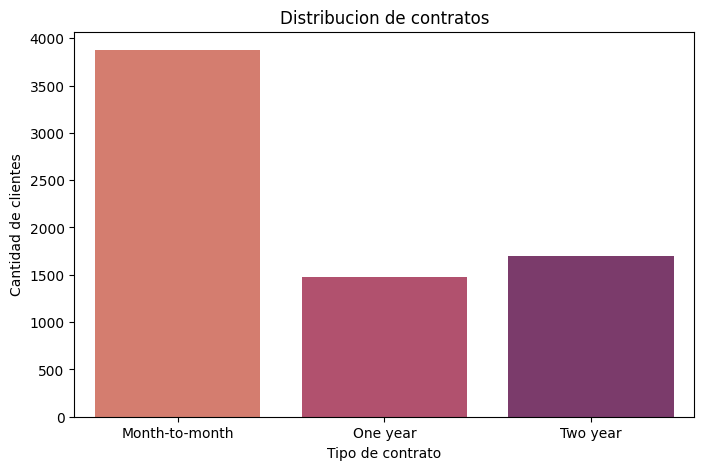

In [333]:
# Para mejor claridad de la información grafico de barras para dibujar el compromiso de sus clientes

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Contract', data=dk, palette='flare', legend=False) # Usando 'flare' para un look más divertido y vibrante, y abordando la advertencia de 'hue'
plt.title('Distribucion de contratos')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.show()

<table width="100%"><tr><td style="background-color:#4B0082; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Análisis de Distribución de Contratos: Se observa que una gran mayoría de clientes opta por contratos mes a mes, lo que indica una menor permanencia a largo plazo.</b></td></tr></table>

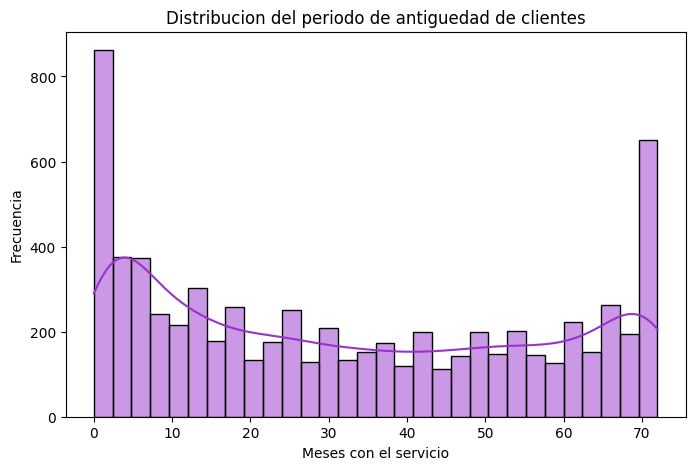

In [334]:
# Ver cuantos clientes son antiguos y nuevos
plt.figure(figsize=(8,5))
sns.histplot(dk['tenure'], bins=30, kde=True, color='darkorchid') # 'darkorchid' para un color divertido y vibrante
plt.title("Distribucion del periodo de antiguedad de clientes")
plt.xlabel('Meses con el servicio')
plt.ylabel('Frecuencia')
plt.show()

<table width="100%"><tr><td style="background-color:#4B0082; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Análisis de Antigüedad de Clientes: El histograma muestra un alto número de clientes nuevos, lo que podría ser una etapa crítica para el churn.</b></td></tr></table>

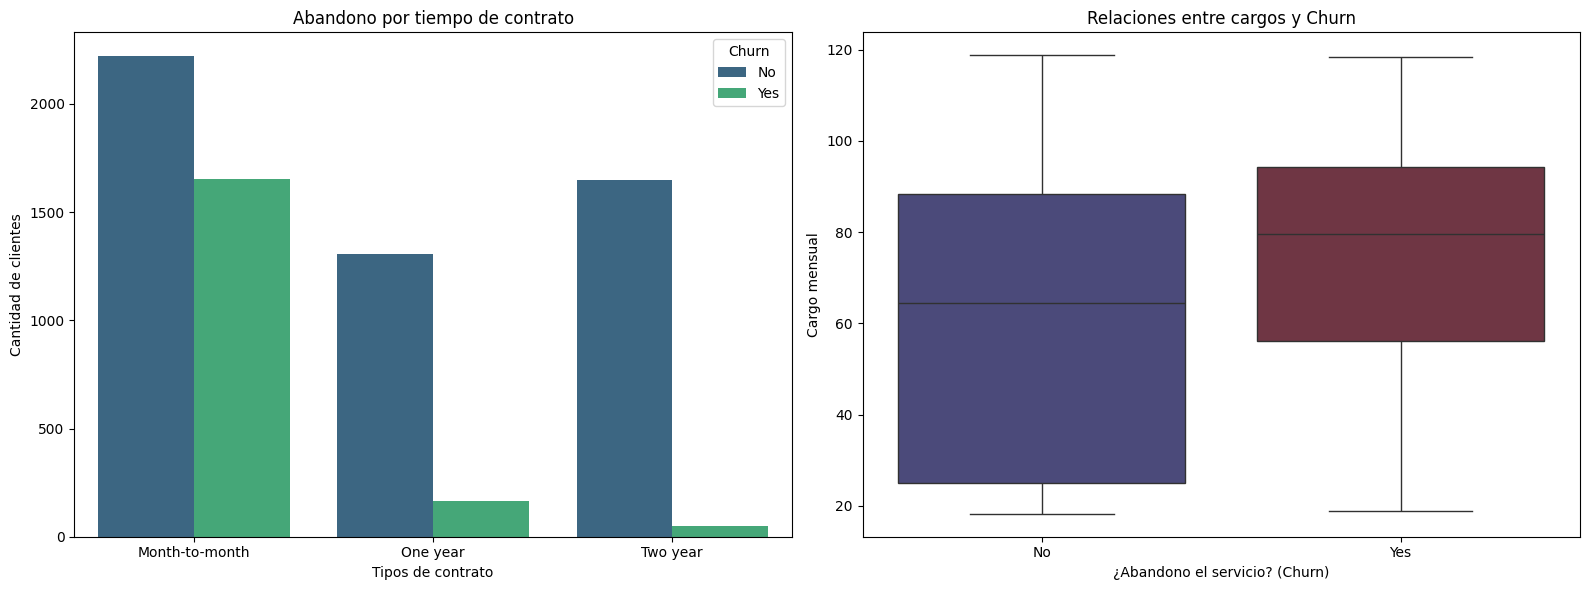

In [335]:
fig, axe = plt.subplots(1,2, figsize=(16,6))
sns.countplot(x='Contract', hue='Churn', data=dk, palette='viridis', ax=axe[0]) # 'viridis' para un contraste vibrante con el Churn
axe[0].set_title('Abandono por tiempo de contrato')
axe[0].set_xlabel('Tipos de contrato')
axe[0].set_ylabel('Cantidad de clientes')

# Corrección del aviso: asignamos x a hue y desactivamos la leyenda redundante
sns.boxplot(x='Churn', y='MonthlyCharges', hue='Churn', data=dk, palette='icefire', ax=axe[1], legend=False)
axe[1].set_title('Relaciones entre cargos y Churn')
axe[1].set_xlabel('¿Abandono el servicio? (Churn)')
axe[1].set_ylabel('Cargo mensual')
plt.tight_layout()
plt.show()

<table width="100%"><tr><td style="background-color:#4B0082; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Interpretación de Abandono y Cargos: Los gráficos revelan que los clientes con contratos 'mes a mes' tienen una tasa de abandono significativamente mayor. Además, el gráfico de caja (boxplot) muestra que los clientes que abandonan suelen tener cargos mensuales más altos en comparación con los que permanecen, sugiriendo que el costo es un factor determinante en la fuga.</b></td></tr></table>

## 6. Matriz de Correlación con One-Hot Encoding

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Para analizar las relaciones entre las variables, utilizamos One-Hot Encoding para convertir las variables categóricas en numéricas, permitiendo así el cálculo de la correlación con Churn.</b></td></tr></table>

In [336]:
# Identificar columnas categóricas para One-Hot Encoding
categorical_cols = dk.select_dtypes(include='string').columns.tolist()
# Excluir 'customerID' ya que es un identificador y 'Churn' será nuestra variable objetivo
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

# Aplicar One-Hot Encoding
dk_encoded = pd.get_dummies(dk, columns=categorical_cols, drop_first=True) # drop_first para evitar la multicolinealidad

# Convertir la variable 'Churn' a numérica (0 para 'No', 1 para 'Yes')
dk_encoded['Churn'] = dk_encoded['Churn'].map({'No': 0, 'Yes': 1})

display(dk_encoded.head())


,customerID,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,0,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,34,56.95,1889.50,0,True,False,False,False,True,...,True,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,1,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,45,42.30,1840.75,0,True,False,False,False,False,...,True,True,False,False,True,False,False,False,False,False
4,9237-HQITU,2,70.70,151.65,1,False,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


### 6.1. Visualización de la Matriz de Correlación

<table width="100%"><tr><td style="background-color:#9146FF; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Calculamos y visualizamos la matriz de correlación completa mediante un mapa de calor para identificar rápidamente qué factores influyen más en el abandono del servicio.</b></td></tr></table>

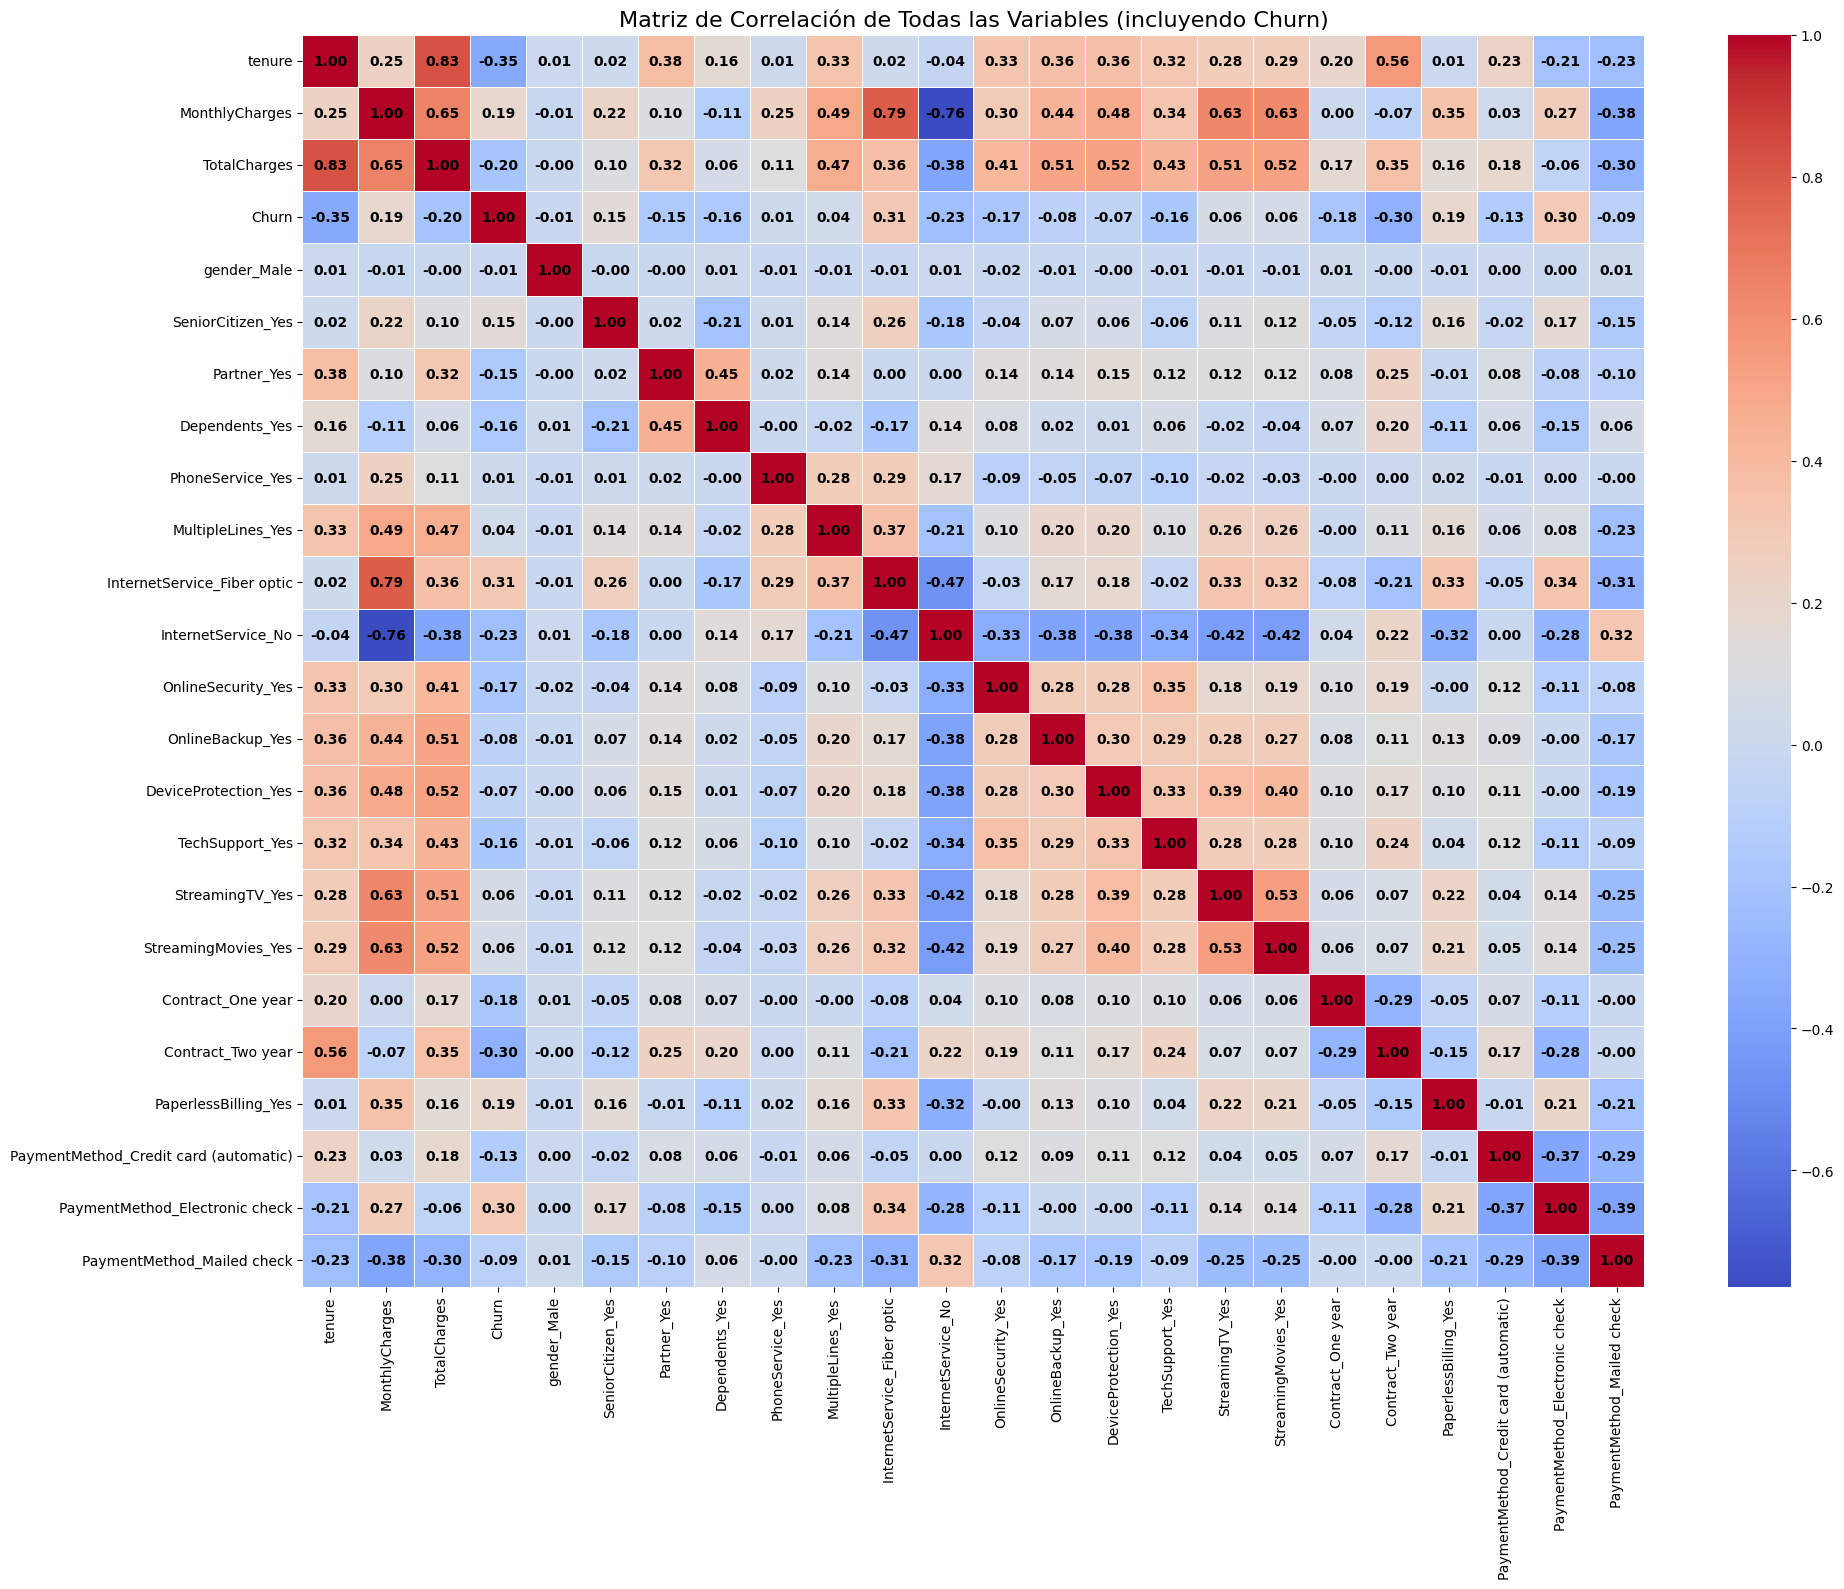

In [337]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
# Excluir 'customerID' antes de calcular la correlación ya que es un identificador
correlation_matrix = dk_encoded.drop(columns=['customerID']).corr()

# Visualizar la matriz de correlación como un mapa de calor
plt.figure(figsize=(20, 16)) # Aumentar el tamaño para mejor visualización
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={
    "color": "black",
    "fontsize": 10,
    "fontweight": "bold"
})
plt.title('Matriz de Correlación de Todas las Variables (incluyendo Churn)', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<table width="100%"><tr><td style="background-color:#4B0082; padding: 15px; border-radius: 8px; border: none; color: white;"><b>Análisis de la Matriz de Correlación: El mapa de calor nos permite identificar visualmente las relaciones fuertes, prestando especial atención a las variables con mayor impacto en el Churn.</b></td></tr></table>